In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

In [56]:
con = duckdb.connect(database='D:/Assets/BinanceFuturesData/binancefuturesdata.duckdb', read_only=True)
query = """
SELECT epoch_ms(timestamp) as time, open, high, low, close, volume 
FROM quote 
WHERE symbol = 'AAVEUSDT' 
  AND epoch_ms(timestamp) >= '2022-01-01 00:00:00' 
  AND epoch_ms(timestamp) < '2025-12-01 00:00:00' 
ORDER BY timestamp;
"""
df_raw = con.execute(query).fetchdf()
con.close()

df_raw['time'] = pd.to_datetime(df_raw['time'])
df_raw.set_index('time', inplace=True)

resample_rules = {'open': 'first', 'high': 'max', 'low': 'min', 'close': 'last', 'volume': 'sum'}
df = df_raw.resample('15min').agg(resample_rules).dropna().reset_index()

df.shape

(137280, 6)

In [57]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

def add_features(df):
    # 이격도 (Z-Score)
    df['ma20'] = df['close'].rolling(window=20).mean()
    df['std20'] = df['close'].rolling(window=20).std()
    df['spread'] = (df['close'] - df['ma20']) / df['std20']
    
    # RSI (과매수/과매도 필터)
    delta = df['close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    df['rsi'] = 100 - (100 / (1 + gain/loss))
    
    # ATR (변동성 필터)
    df['tr'] = np.maximum(df['high'] - df['low'], 
                          np.maximum(abs(df['high'] - df['close'].shift(1)), 
                                     abs(df['low'] - df['close'].shift(1))))
    df['atr'] = df['tr'].rolling(window=14).mean()
    return df.dropna()

df_feat = add_features(df.copy())

features = ['spread', 'rsi', 'atr', 'volume']
target = 'spread'
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_feat[features])

def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        xs.append(data[i:(i + seq_length)])
        ys.append(data[i + seq_length, 0]) # 다음 봉의 spread 예측
    return np.array(xs), np.array(ys)

seq_length = 48 # 과거 2일치 데이터 학습
X, y = create_sequences(scaled_data, seq_length)
split = int(len(X) * 0.8)

train_x = torch.FloatTensor(X[:split])
train_y = torch.FloatTensor(y[:split])
test_x = torch.FloatTensor(X[split:])
test_y = torch.FloatTensor(y[split:])

In [58]:
class TimeSeriesTransformer(nn.Module):
    def __init__(self, input_dim, d_model, nhead, num_layers, dropout=0.2):
        super().__init__()
        self.input_linear = nn.Linear(input_dim, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_linear = nn.Linear(d_model, 1)
        
    def forward(self, src):
        src = self.input_linear(src)
        out = self.transformer_encoder(src)
        return self.output_linear(out[:, -1, :])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TimeSeriesTransformer(input_dim=len(features), d_model=64, nhead=4, num_layers=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
criterion = nn.MSELoss()

In [13]:
train_loader = DataLoader(list(zip(train_x, train_y)), batch_size=32, shuffle=True)

# 1. 데이터 확인 (이게 제대로 나와야 함)
print(f"X shape: {train_x.shape}") # [전체데이터수, 48, 4] 형태여야 함
print(f"y shape: {train_y.shape}") # [전체데이터수] 형태여야 함

# 2. 학습 루프 수정
from tqdm.auto import tqdm

epochs = 30
model.train()

for epoch in range(epochs):
    epoch_loss = 0
    # 배치 단위로 tqdm을 걸어서 어디서 멈추는지 확인
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False)
    
    for bx, by in train_pbar:
        bx, by = bx.to(device), by.to(device)
        
        optimizer.zero_grad()
        outputs = model(bx).view(-1) # squeeze() 대신 확실하게 1차원으로 펼침
        
        # 차원이 맞는지 체크 (최초 1회만 출력)
        if epoch == 0 and train_pbar.n == 0:
            print(f"\nModel output shape: {outputs.shape}")
            print(f"Target y shape: {by.shape}")

        loss = criterion(outputs, by)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        # 배치마다 현재 loss를 pbar에 업데이트
        train_pbar.set_postfix(loss=loss.item())

    print(f"Epoch {epoch+1} Completed. Avg Loss: {epoch_loss/len(train_loader):.6f}")

X shape: torch.Size([109755, 48, 4])
y shape: torch.Size([109755])


Epoch 1:   0%|          | 0/3430 [00:00<?, ?it/s]


Model output shape: torch.Size([32])
Target y shape: torch.Size([32])

Model output shape: torch.Size([32])
Target y shape: torch.Size([32])

Model output shape: torch.Size([32])
Target y shape: torch.Size([32])
Epoch 1 Completed. Avg Loss: 0.286722


Epoch 2:   0%|          | 0/3430 [00:00<?, ?it/s]

Epoch 2 Completed. Avg Loss: 0.284930


...

Epoch 28 Completed. Avg Loss: 0.279115


Epoch 29:   0%|          | 0/3430 [00:00<?, ?it/s]

Epoch 29 Completed. Avg Loss: 0.279257


Epoch 30:   0%|          | 0/3430 [00:00<?, ?it/s]

Epoch 30 Completed. Avg Loss: 0.279066


In [30]:
# 모델의 state_dict(가중치 데이터) 저장
torch.save(model.state_dict(), "transformer1_model.pth")

In [59]:
model.eval()
with torch.no_grad():
    preds = model(test_x.to(device)).cpu().numpy()

--- 최종 결과 ---
누적 수익률: 0.9251
MDD: -21.06%
매매 횟수: 177회
승률: 59.89%


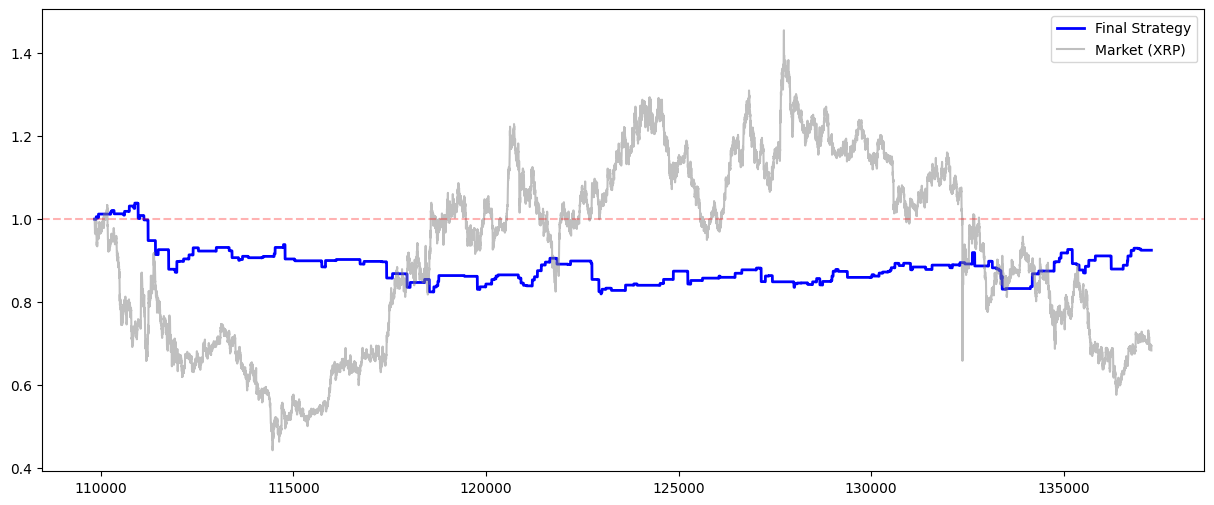

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. 데이터프레임 재구성 (에러 방지용)
# 모델 예측값(preds)과 원본 데이터(df_feat)를 확실하게 병합합니다.
backtest_start_idx = split + seq_length
df_final = df_feat.iloc[backtest_start_idx:].copy()
df_final['pred_spread'] = preds.flatten() # 예측값 추가
df_final['ma200'] = df_feat['close'].rolling(window=200).mean().iloc[backtest_start_idx:]

# 최적 파라미터 설정
best_params = {
    'stop_loss_pct': 0.0333,
    'take_profit_pct': 0.0599,
    'upper_limit': 2.1218,
    'lower_limit': -2.4162,
    'rsi_buy': 38,
    'rsi_sell': 63
}

fee = 0.0004  # 바이낸스 선물 수수료 (0.04%)

# 시뮬레이션 상태 변수
position = 0
entry_price = 0
strategy_returns = np.zeros(len(df_final))
trade_history = []

# 2. 시뮬레이션 루프
for i in range(len(df_final)):
    row = df_final.iloc[i]
    curr_price = row['close']
    spr = row['spread']
    rsi = row['rsi']
    pred = row['pred_spread']
    ma200 = row['ma200']
    
    # MA200이 계산되지 않은 초기 데이터는 스킵
    if pd.isna(ma200):
        continue

    if position == 0:
        # [롱 진입] 상승 추세 + 과매도 + 모델 반등 예측
        if (curr_price > ma200) and (spr < best_params['lower_limit']) and \
           (rsi < best_params['rsi_buy']) and (pred > spr + 0.6):
            position = 1
            entry_price = curr_price
            strategy_returns[i] -= fee # 진입 수수료
            
        # [숏 진입] 하락 추세 + 과매수 + 모델 하락 예측
        elif (curr_price < ma200) and (spr > best_params['upper_limit']) and \
             (rsi > best_params['rsi_sell']) and (spr - pred > 0.6):
            position = -1
            entry_price = curr_price
            strategy_returns[i] -= fee # 진입 수수료
            
    elif position == 1: # 롱 포지션 관리
        pnl = (curr_price - entry_price) / entry_price
        # 손절, 익절, 또는 이격 해소 시 탈출
        if (pnl <= -best_params['stop_loss_pct']) or \
           (pnl >= best_params['take_profit_pct']) or (spr >= -0.1):
            position = 0
            strategy_returns[i] += pnl - fee
            trade_history.append(pnl - (fee * 2))
            
    elif position == -1: # 숏 포지션 관리
        pnl = (entry_price - curr_price) / entry_price
        if (pnl <= -best_params['stop_loss_pct']) or \
           (pnl >= best_params['take_profit_pct']) or (spr <= 0.1):
            position = 0
            strategy_returns[i] += pnl - fee
            trade_history.append(pnl - (fee * 2))

# 3. 결과 요약 및 시각화
df_final['strat_cum_ret'] = (1 + strategy_returns).cumprod()
df_final['market_cum_ret'] = df_final['close'] / df_final['close'].iloc[0]

mdd = (df_final['strat_cum_ret'] / df_final['strat_cum_ret'].cummax() - 1).min()
win_rate = len([r for r in trade_history if r > 0]) / len(trade_history) if trade_history else 0

print(f"--- 최종 결과 ---")
print(f"누적 수익률: {df_final['strat_cum_ret'].iloc[-1]:.4f}")
print(f"MDD: {mdd:.2%}")
print(f"매매 횟수: {len(trade_history)}회")
print(f"승률: {win_rate:.2%}")

# 차트 출력
plt.figure(figsize=(15, 6))
plt.plot(df_final['strat_cum_ret'], label='Final Strategy', color='blue', linewidth=2)
plt.plot(df_final['market_cum_ret'], label='Market (XRP)', color='gray', alpha=0.5)
plt.axhline(1, color='red', linestyle='--', alpha=0.3)
plt.legend()
plt.show()

In [ ]:
import optuna

def objective(trial):
    # 1. 탐색할 파라미터 범위 설정
    sl_pct = trial.suggest_float('stop_loss_pct', 0.015, 0.035)
    tp_pct = trial.suggest_float('take_profit_pct', 0.03, 0.07)
    u_limit = trial.suggest_float('upper_limit', 2.0, 3.5)
    l_limit = trial.suggest_float('lower_limit', -3.5, -2.0)
    rsi_buy = trial.suggest_int('rsi_buy', 20, 40)
    rsi_sell = trial.suggest_int('rsi_sell', 60, 80)
    
    # 2. 시뮬레이션 초기화
    position = 0
    entry_price = 0
    strategy_returns = np.zeros(len(df_sim))
    fee = 0.0004

    # 3. 시뮬레이션 루프 (속도를 위해 벡터화 대신 루프 사용)
    for i in range(200, len(df_sim)):
        curr_price = df_sim['close'].iloc[i]
        spr = df_sim['spread'].iloc[i]
        rsi = df_sim['rsi'].iloc[i]
        pred = df_sim['pred_spread'].iloc[i]
        ma200 = df_sim['ma200'].iloc[i]
        
        if position == 0:
            if (curr_price > ma200) and (spr < l_limit) and (rsi < rsi_buy) and (pred > spr + 0.6):
                position = 1
                entry_price = curr_price
                strategy_returns[i] -= fee
            elif (curr_price < ma200) and (spr > u_limit) and (rsi > rsi_sell) and (spr - pred > 0.6):
                position = -1
                entry_price = curr_price
                strategy_returns[i] -= fee
        elif position == 1:
            pnl = (curr_price - entry_price) / entry_price
            if (pnl <= -sl_pct) or (pnl >= tp_pct) or (spr >= -0.1):
                position = 0
                strategy_returns[i] += pnl - fee
        elif position == -1:
            pnl = (entry_price - curr_price) / entry_price
            if (pnl <= -sl_pct) or (pnl >= tp_pct) or (spr <= 0.1):
                position = 0
                strategy_returns[i] += pnl - fee

    # 4. 평가 지표 계산 (수익률 + MDD 패널티)
    cum_ret = np.prod(1 + strategy_returns)
    
    # 매매 횟수가 너무 적으면(예: 30회 미만) 신뢰도가 낮으므로 낮은 점수 부여
    trade_count = np.count_nonzero(strategy_returns)
    if trade_count < 30:
        return 0.0

    return cum_ret

# 5. 최적화 실행
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100) # 100번의 조합 테스트

print("최고 수익률:", study.best_value)
print("최적 파라미터:", study.best_params)

[I 2025-12-26 22:27:34,562] A new study created in memory with name: no-name-910e376b-e20f-424e-800e-e69ba8544cdb
[I 2025-12-26 22:27:34,940] Trial 0 finished with value: 1.173560806628772 and parameters: {'stop_loss_pct': 0.023662577857386458, 'take_profit_pct': 0.04795232054636243, 'upper_limit': 2.329327900318717, 'lower_limit': -2.0832023079595126, 'rsi_buy': 32, 'rsi_sell': 63}. Best is trial 0 with value: 1.173560806628772.
[I 2025-12-26 22:27:35,311] Trial 1 finished with value: 0.0 and parameters: {'stop_loss_pct': 0.023714327783787063, 'take_profit_pct': 0.04972786305484607, 'upper_limit': 3.1961339337448202, 'lower_limit': -2.8914605101803144, 'rsi_buy': 31, 'rsi_sell': 70}. Best is trial 0 with value: 1.173560806628772.
[I 2025-12-26 22:27:35,691] Trial 2 finished with value: 1.2144190193947841 and parameters: {'stop_loss_pct': 0.029532109779300743, 'take_profit_pct': 0.05323347569923613, 'upper_limit': 3.4997298597237183, 'lower_limit': -2.5281119306766215, 'rsi_buy': 36, '

최고 수익률: 1.4727118954440443
최적 파라미터: {'stop_loss_pct': 0.033337208956298756, 'take_profit_pct': 0.059937990066974964, 'upper_limit': 2.1218121857650685, 'lower_limit': -2.4161818177205743, 'rsi_buy': 38, 'rsi_sell': 63}
